In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
import zipfile
import os

if not os.path.exists("dataset"):
    os.makedirs("dataset")

print("Please upload your zipped dataset folder:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"User uploaded file \"{fn}\"")
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall("dataset/")
        print(f"Successfully extracted {fn} to 'dataset/'")
        os.remove(fn)
    else:
        print(f"Skipping non-zip file: {fn}")

print("Dataset upload and extraction complete.")

Please upload your zipped dataset folder:


Saving Copy of devnagari digit.zip to Copy of devnagari digit.zip
User uploaded file "Copy of devnagari digit.zip"
Successfully extracted Copy of devnagari digit.zip to 'dataset/'
Dataset upload and extraction complete.


###Task 1: Data Preparation Loading the Data

Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Train: (17000, 784) (17000, 10)
Test : (3000, 784) (3000, 10)


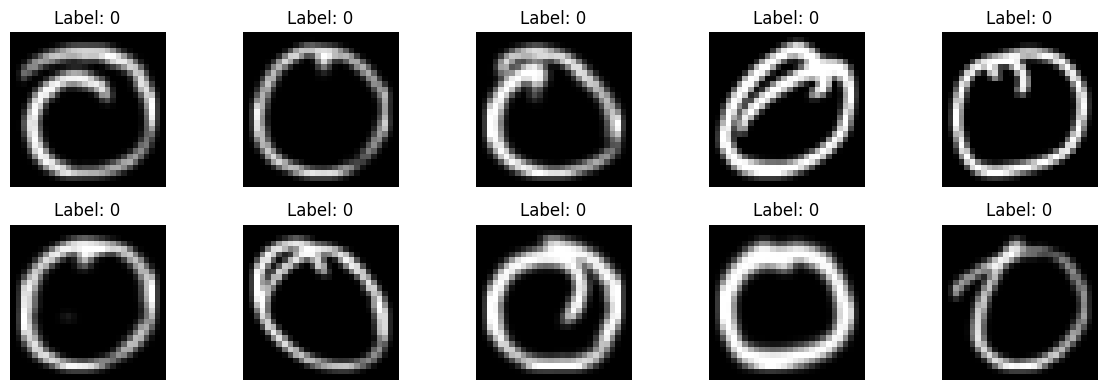

In [3]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

base_path = 'dataset/DevanagariHandwrittenDigitDataset'

train_dir = os.path.join(base_path, 'Train')
test_dir  = os.path.join(base_path, 'Test')

IMG_SIZE = 28

def load_data(data_dir):
    images = []
    labels = []

    # Sort folders to keep label order consistent
    class_names = sorted(os.listdir(data_dir))

    print("Classes:", class_names)

    for label, folder_name in enumerate(class_names):
        folder_path = os.path.join(data_dir, folder_name)

        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)

            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize((IMG_SIZE, IMG_SIZE))  # resize

                img_array = np.array(img)

                images.append(img_array)
                labels.append(label)

            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue

    return np.array(images), np.array(labels), class_names

# Load Dataset

X_train, y_train, class_names = load_data(train_dir)
X_test, y_test, _ = load_data(test_dir)

# Normalize
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Flatten (FCN input)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

# One-hot Encoding
num_classes = len(class_names)

y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test, num_classes)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Task 2: Build the FCN Model
Model Architecture
• Create a Sequential model using Keras.
• Add 3 hidden layers with the following number of neurons:
– 1st hidden layer: 64 neurons
– 2nd hidden layer: 128 neurons
– 3rd hidden layer: 256 neurons
• Use sigmoid activation functions for all hidden layers.
• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build FCN Model
model = Sequential()

# Input + 1st Hidden Layer (64 neurons)
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))

# 2nd Hidden Layer (128 neurons)
model.add(Dense(128, activation='sigmoid'))

# 3rd Hidden Layer (256 neurons)
model.add(Dense(256, activation='sigmoid'))

# Output Layer (10 classes)
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

Task 3: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model Model Training

In [6]:
from tensorflow import keras


callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2679 - loss: 1.9239
Epoch 1: val_loss improved from None to 8.30206, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4508 - loss: 1.5887 - val_accuracy: 0.0000e+00 - val_loss: 8.3021
Epoch 2/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8058 - loss: 0.6706
Epoch 2: val_loss did not improve from 8.30206
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8509 - loss: 0.5202 - val_accuracy: 0.0000e+00 - val_loss: 9.4474
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9160 - loss: 0.2926
Epoch 3: val_loss did not improve from 8.30206
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9270 - loss: 0.2615 - val_accuracy: 0.0000e+00 - val_loss: 10.2663
Epoch 4/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9481 - loss: 0.1929
Epoch 4: val_loss did not improve from 8.30

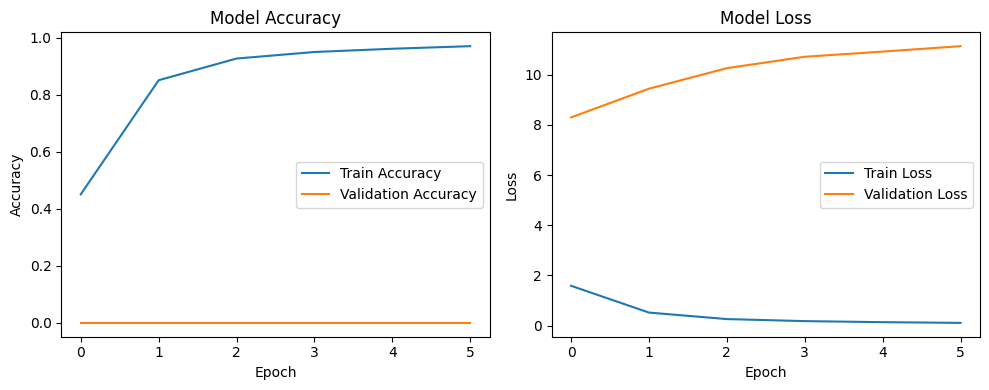

In [7]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


# Plot Loss

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Task 5: Evaluate the Model Model Evaluation

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5973 - loss: 2.3354
Test Loss: 2.3353846073150635
Test Accuracy: 0.5973333120346069


Task 6: Save and Load the Model Model Saving and Loading

In [9]:
model.save("devnagari_fcn_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [10]:
import tensorflow as tf

model_file = "devnagari_fcn_model.h5"

# Load model
loaded_model = tf.keras.models.load_model(model_file)
print(f"Model loaded from '{model_file}'")

# Evaluate model
loaded_loss, loaded_accuracy = loaded_model.evaluate(X_test, y_test, verbose=2)

print(f"\nLoaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_accuracy * 100:.2f}%")

Model loaded from 'devnagari_fcn_model.h5'
94/94 - 1s - 7ms/step - accuracy: 0.5973 - loss: 2.3354

Loaded Model Test Loss     : 2.3354
Loaded Model Test Accuracy : 59.73%


Task 7: Predictions Making Predictions

First Image Prediction : 0
Actual Label           : 0


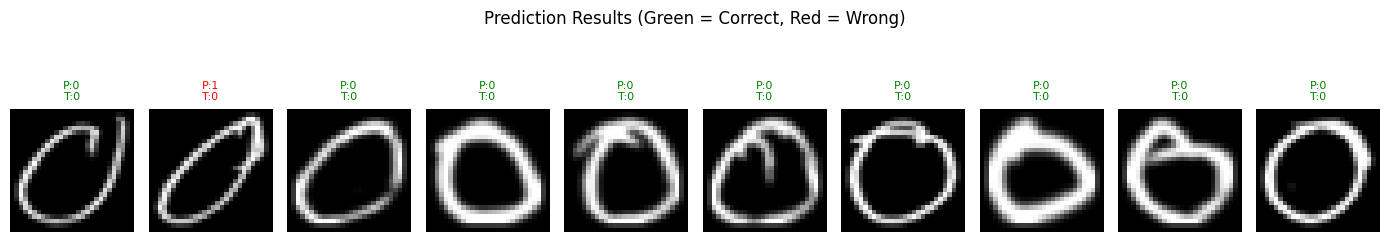

Prediction image saved as 'task7_predictions.png'


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Make Predictions
probabilities = loaded_model.predict(X_test, verbose=0)

# Convert probabilities → labels
predicted_classes = np.argmax(probabilities, axis=1)
actual_classes = np.argmax(y_test, axis=1)

# Show First Prediction
print("First Image Prediction :", predicted_classes[0])
print("Actual Label           :", actual_classes[0])

# Visualize Predictions
num_display = 10
plt.figure(figsize=(14, 3))

for i in range(num_display):
    plt.subplot(1, num_display, i + 1)

    # reshape flattened image for display
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    pred = predicted_classes[i]
    true = actual_classes[i]

    # green = correct, red = wrong
    color = "green" if pred == true else "red"

    plt.title(f"P:{pred}\nT:{true}", color=color, fontsize=8)
    plt.axis('off')

plt.suptitle("Prediction Results (Green = Correct, Red = Wrong)")
plt.tight_layout()
plt.savefig("task7_predictions.png", dpi=150)
plt.show()

print("Prediction image saved as 'task7_predictions.png'")

Confusion Matrix

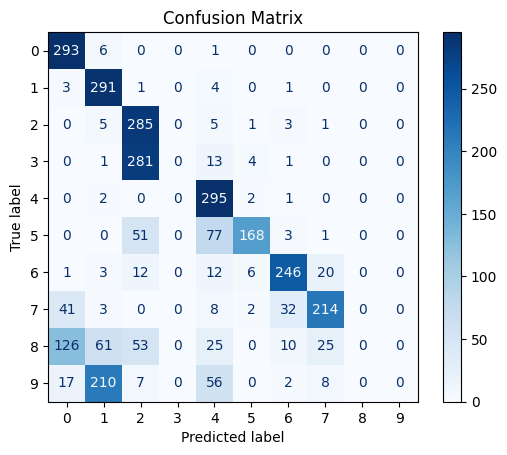

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(actual_classes, predicted_classes)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

Classification Report

In [13]:
from sklearn.metrics import classification_report

print(classification_report(actual_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.61      0.98      0.75       300
           1       0.50      0.97      0.66       300
           2       0.41      0.95      0.58       300
           3       0.00      0.00      0.00       300
           4       0.59      0.98      0.74       300
           5       0.92      0.56      0.70       300
           6       0.82      0.82      0.82       300
           7       0.80      0.71      0.75       300
           8       0.00      0.00      0.00       300
           9       0.00      0.00      0.00       300

    accuracy                           0.60      3000
   macro avg       0.47      0.60      0.50      3000
weighted avg       0.47      0.60      0.50      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
